In [57]:
import sys, os
import pickle
import numpy as np
import pandas as pd
from scipy.stats import beta
import time
import joblib
from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import contextlib

In [58]:
np.random.seed(1000)
sign_level = np.array([0.01, 0.05, 0.1])
param_grid = {
    'min_samples_leaf': [1, 5, 10],
    'max_features': [1, 2]
    }

In [59]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument"""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

def tune_forest(X, y, param_grid, random_state=1000):
    """Perform hyperparameter tuning using GridSearchCV."""
    base_forest = RandomForestRegressor(n_jobs=-1, random_state=random_state, n_estimators=200, oob_score=True)
    grid_search = GridSearchCV(estimator = base_forest, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=0)
    grid_search.fit(X, y)
    return grid_search.best_estimator_

In [60]:
with open(os.path.join(os.getcwd(), 'sunspots', 'data', 'sunspots_data.csv'), 'rb') as f:
    sample = pd.read_csv(f)

sample.drop(columns = ['Unnamed: 0'], inplace = True)

train_theta_x = sample['V1'].to_numpy()[:-500]
train_phi_x = sample['V2'].to_numpy()[:-500]
train_theta_y = sample['V3'].to_numpy()[:-500]
train_phi_y = sample['V4'].to_numpy()[:-500]

test_theta_x = sample['V1'].to_numpy()[-500:]
test_phi_x = sample['V2'].to_numpy()[-500:]
test_theta_y = sample['V3'].to_numpy()[-500:]
test_phi_y = sample['V4'].to_numpy()[-500:]

train_predictors = np.vstack((train_theta_x, train_phi_x)).T
test_predictors = np.vstack((test_theta_x, test_phi_x)).T
# Perform hyperparameter tuning
theta_forest = tune_forest(train_predictors, train_theta_y, param_grid) 
phi_forest = tune_forest(train_predictors, train_phi_y, param_grid)
# Radii
theta_oob_quantile = np.percentile(np.abs(theta_forest.oob_prediction_ - train_theta_y), (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')
phi_oob_quantile = np.percentile(np.abs(phi_forest.oob_prediction_ - train_phi_y), (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')

In [ ]:
# Load model results (replace with your own file)
results_dir = os.path.join(os.getcwd(), 'simulations_euc', 'sklearn_results')
result_filename = 'euc_samp1_N50_sigma0.1_results.npy'  # Example filename
result_file_path = os.path.join(results_dir, result_filename)

# Load the results file
results = np.load(result_file_path, allow_pickle=True).item()

# Extract the trained Random Forest model and the data
random_forest = results['forest']
X_train = results['x_data']
y_train = results['y_data']

# Define the features of interest
features_info = {
    "features": [0, 1, 2, 3, 4],  # Using the first 5 features
    "kind": "average",  # Type of partial dependence plot (average over other features)
}

common_params = {
    "subsample": 50,
    "n_jobs": 2,
    "grid_resolution": 50,
    "random_state": 0,
}

# Theoretical partial dependence functions
def em_1(x):
    return -2 - 2*x + 4/np.pi + 11/12

def em_2(x):
    return -7/3 + 2*np.sin(np.pi*x) + 1/2*x

def em_3(x):
    return 4/np.pi - 7/4 - x**2

def em_4(x):
    return 4/np.pi - 7/3 + x/2

def em_5(x):
    return 4/np.pi - 37/12 + 2*x

# Generate x values for plotting the theoretical functions
x = np.linspace(0, 1, 100)

# Create the plot
print("Computing partial dependence plots...")
tic = time()

# Set custom matplotlib style
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-notebook")
_, ax = plt.subplots(ncols=1, nrows=5, figsize=(9, 8), constrained_layout=True)

# Generate the Partial Dependence Display
display = PartialDependenceDisplay.from_estimator(
    random_forest, 
    X_train, 
    **features_info, 
    ax=ax, 
    **common_params
)

# Plot the theoretical functions on top of the PDP
for i, feature in enumerate(features_info["features"]):
    # Corresponding theoretical function (em_1, em_2, ..., em_5)
    if i == 0:
        ax[i].plot(x, em_1(x), label='$E(m(X)|X_1=x)$', color='red', linestyle='--')
    elif i == 1:
        ax[i].plot(x, em_2(x), label='$E(m(X)|X_2=x)$', color='red', linestyle='--')
    elif i == 2:
        ax[i].plot(x, em_3(x), label='$E(m(X)|X_3=x)$', color='red', linestyle='--')
    elif i == 3:
        ax[i].plot(x, em_4(x), label='$E(m(X)|X_4=x)$', color='red', linestyle='--')
    elif i == 4:
        ax[i].plot(x, em_5(x), label='$E(m(X)|X_5=x)$', color='red', linestyle='--')

    # Adjusting y-limits to fit the theoretical function
    # Calculate the min and max of the theoretical function values to ensure they fit within the frame
    min_theoretical = min([eval(f"em_{i+1}(x)").min() for i in range(5)])
    max_theoretical = max([eval(f"em_{i+1}(x)").max() for i in range(5)])
    ax[i].set_ylim(min_theoretical * 1.1, max_theoretical * 1.1)  # Add some padding around the theoretical values

    # Set title and label for each subplot
    ax[i].set_title(f'Partial Dependence for Feature {feature}')
    ax[i].set_xlabel(f'Feature {feature}')
    ax[i].set_ylabel('Partial dependence')

    # Add a legend
    ax[0].legend()

# Print how long it took to compute
print(f"done in {time() - tic:.3f}s")

# Add a title to the figure
plt.suptitle(
    "Partial dependence plots with Theoretical Functions\n"
    "Simulated data with 5 features",
    fontsize=16
)

# Show the plot
plt.show()

11
12
13
14
15
16
17
18
19
20
21
22
23
24


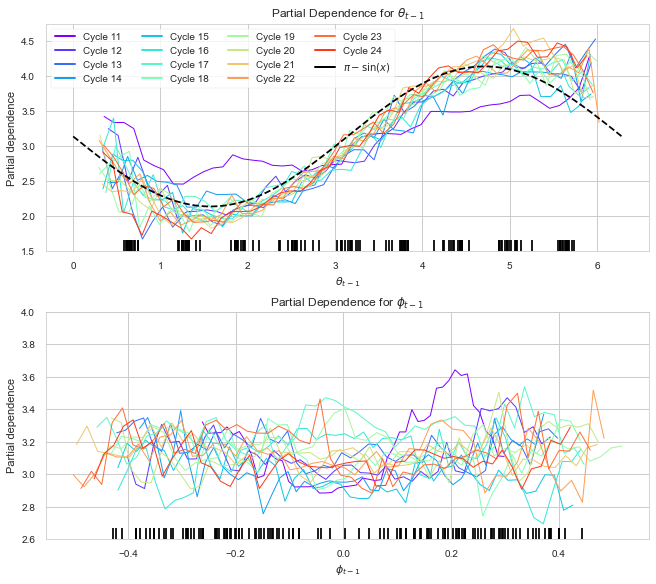

In [168]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D  # For adding custom legends

# List of all random forests (loaded in a loop)
random_forests = []
X_trains = []
y_trains = []

def em_1(x):
    return (np.pi - np.sin(x))
# Loop through the 30 models
for i in range(11, 25):
    print(i)
    with open(os.path.join(os.getcwd(), 'sunspots', 'data', 'sunspots_cycle_' + str(i) + '.csv'), 'rb') as f:
        sample = pd.read_csv(f)
    sample.drop(columns = ['Unnamed: 0'], inplace = True)
    train_theta_x = sample['theta_pred'].to_numpy()
    train_phi_x = sample['phi_pred'].to_numpy()
    train_theta_y = sample['theta_resp'].to_numpy()
    train_phi_y = sample['phi_resp'].to_numpy()

    train_predictors = np.vstack((train_theta_x, train_phi_x)).T
    # Perform hyperparameter tuning
    theta_forest = tune_forest(train_predictors, train_theta_y, param_grid)
    random_forests.append(theta_forest)
    X_trains.append(train_predictors)
    y_trains.append(train_theta_y)

# Define the features of interest (same for all models)
features_info = {
    "features": [0, 1], 
    "kind": "average",  # Type of partial dependence plot (average over other features)
}

common_params = {
    "subsample": 50,
    "n_jobs": 10,
    "grid_resolution": 50,
    "random_state": 0,
}

# Set custom matplotlib style
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-notebook")

# Create a subplot for the PDPs of all models
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(9, 8), constrained_layout=True)

# Create a colormap for the lines using 'rainbow' colormap
cmap = plt.cm.rainbow  # Use the rainbow colormap

# Loop through all Random Forests and plot their partial dependence plots
line_kw = {"linewidth": 1}  # Set the desired linewidth here

# Create a list for the custom legend elements
legend_elements = []

for j, random_forest in enumerate(random_forests):
    # Generate a color for each model based on the cycle index
    color = cmap(j / len(random_forests))  # Normalize the index to get a color from the colormap
    
    # Set the color for the current line (inside line_kw dictionary)
    line_kw["color"] = color
    
    # Generate the Partial Dependence Display for the current Random Forest
    display = PartialDependenceDisplay.from_estimator(
        random_forest, 
        X_trains[j], 
        **features_info, 
        ax=ax, 
        line_kw=line_kw,  # Apply the linewidth and color setting inside line_kw
        **common_params
    )
    
    # Add the line to the custom legend (use the cycle number for label)
    legend_elements.append(Line2D([0], [0], color=color, lw=2, label=f"Cycle {j + 11}"))

x = np.linspace(0, 2*np.pi, 100)
# Plot the theoretical functions on top of the PDP
for i, feature in enumerate(features_info["features"]):
    # Corresponding theoretical function (em_1, em_2, ..., em_5)
    if i == 0:
        ax[i].plot(x, em_1(x), color='black', linestyle='--')
        legend_elements.append(Line2D([0], [0], color='black', lw=2, label=r"$\pi - \sin(x)$"))
        ax[i].set_title(r'Partial Dependence for $\theta_{{t-1}}$')
        ax[i].set_xlabel(r'$\theta_{t-1}$')
        ax[i].set_ylabel('Partial dependence')
    # Set title and label for each subplot
    else:
        ax[i].set_title(r'Partial Dependence for $\phi_{{t-1}}$')
        ax[i].set_xlabel(r'$\phi_{t-1}$')
        ax[i].set_ylabel('Partial dependence')

# Fix y-axis limits for each subplot
ax[0].set_ylim(1.5, 4.75)
ax[1].set_ylim(2.6, 4)

# Add the legend to the plot
ax[0].legend(handles=legend_elements, loc="upper left", fontsize=10, ncols = 4)

plt.show()

11
12
13
14
15
16
17
18
19
20
21
22
23
24


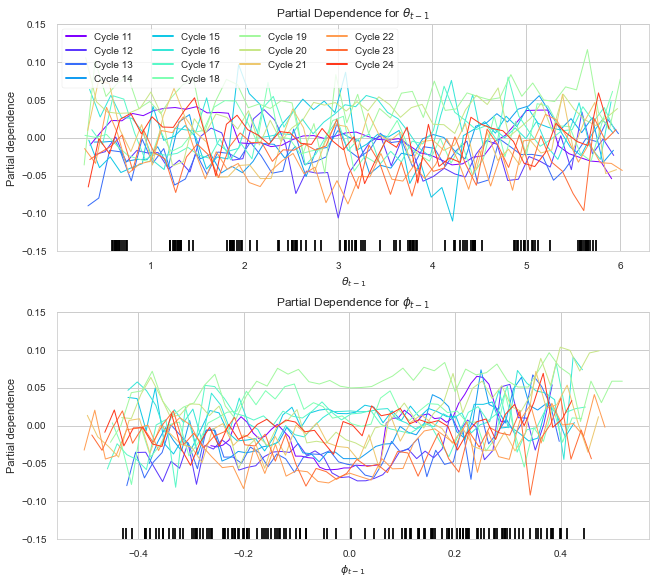

In [170]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D  # For adding custom legends

# List of all random forests (loaded in a loop)
random_forests = []
X_trains = []
y_trains = []

def em_1(x):
    return (np.pi - np.sin(x))
# Loop through the 30 models
for i in range(11, 25):
    print(i)
    with open(os.path.join(os.getcwd(), 'sunspots', 'data', 'sunspots_cycle_' + str(i) + '.csv'), 'rb') as f:
        sample = pd.read_csv(f)
    sample.drop(columns = ['Unnamed: 0'], inplace = True)
    train_theta_x = sample['theta_pred'].to_numpy()
    train_phi_x = sample['phi_pred'].to_numpy()
    train_theta_y = sample['theta_resp'].to_numpy()
    train_phi_y = sample['phi_resp'].to_numpy()

    train_predictors = np.vstack((train_theta_x, train_phi_x)).T
    # Perform hyperparameter tuning
    theta_forest = tune_forest(train_predictors, train_phi_y, param_grid)
    random_forests.append(theta_forest)
    X_trains.append(train_predictors)
    y_trains.append(train_phi_y)

# Define the features of interest (same for all models)
features_info = {
    "features": [0, 1], 
    "kind": "average",  # Type of partial dependence plot (average over other features)
}

common_params = {
    "subsample": 50,
    "n_jobs": 10,
    "grid_resolution": 50,
    "random_state": 0,
}

# Set custom matplotlib style
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-notebook")

# Create a subplot for the PDPs of all models
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(9, 8), constrained_layout=True)

# Create a colormap for the lines using 'rainbow' colormap
cmap = plt.cm.rainbow  # Use the rainbow colormap

# Loop through all Random Forests and plot their partial dependence plots
line_kw = {"linewidth": 1}  # Set the desired linewidth here

# Create a list for the custom legend elements
legend_elements = []

for j, random_forest in enumerate(random_forests):
    # Generate a color for each model based on the cycle index
    color = cmap(j / len(random_forests))  # Normalize the index to get a color from the colormap
    
    # Set the color for the current line (inside line_kw dictionary)
    line_kw["color"] = color
    
    # Generate the Partial Dependence Display for the current Random Forest
    display = PartialDependenceDisplay.from_estimator(
        random_forest, 
        X_trains[j], 
        **features_info, 
        ax=ax, 
        line_kw=line_kw,  # Apply the linewidth and color setting inside line_kw
        **common_params
    )
    
    # Add the line to the custom legend (use the cycle number for label)
    legend_elements.append(Line2D([0], [0], color=color, lw=2, label=f"Cycle {j + 11}"))

x = np.linspace(0, 2*np.pi, 100)
# Plot the theoretical functions on top of the PDP
for i, feature in enumerate(features_info["features"]):
    # Corresponding theoretical function (em_1, em_2, ..., em_5)
    if i == 0:
        ax[i].set_title(r'Partial Dependence for $\theta_{{t-1}}$')
        ax[i].set_xlabel(r'$\theta_{t-1}$')
        ax[i].set_ylabel('Partial dependence')
    # Set title and label for each subplot
    else:
        ax[i].set_title(r'Partial Dependence for $\phi_{{t-1}}$')
        ax[i].set_xlabel(r'$\phi_{t-1}$')
        ax[i].set_ylabel('Partial dependence')

# Fix y-axis limits for each subplot
ax[0].set_ylim(-0.15, 0.15)
ax[1].set_ylim(-0.15, 0.15)

# Add the legend to the plot
ax[0].legend(handles=legend_elements, loc="upper left", fontsize=10, ncols = 4)

plt.show()

19


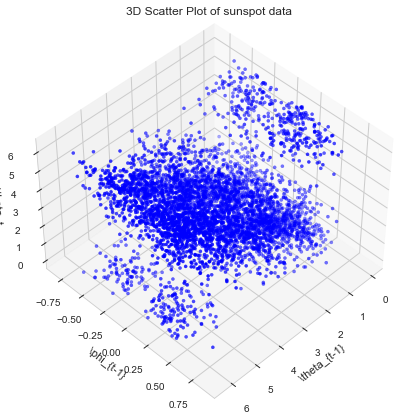

In [189]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting

# Assuming your data is already loaded, for example:
# train_theta_x, train_phi_x, and train_theta_y are already defined as arrays
for i in range(19, 20):
    print(i)
    with open(os.path.join(os.getcwd(), 'sunspots', 'data', 'sunspots_cycle_' + str(i) + '.csv'), 'rb') as f:
        sample = pd.read_csv(f)
    sample.drop(columns = ['Unnamed: 0'], inplace = True)
    train_theta_x = sample['theta_pred'].to_numpy()
    train_phi_x = sample['phi_pred'].to_numpy()
    train_theta_y = sample['theta_resp'].to_numpy()
    train_phi_y = sample['phi_resp'].to_numpy()

    train_predictors = np.vstack((train_theta_x, train_phi_x)).T
    # Perform hyperparameter tuning
    theta_forest = tune_forest(train_predictors, train_phi_y, param_grid)
    random_forests.append(theta_forest)
    X_trains.append(train_predictors)
    y_trains.append(train_phi_y)

    # Create a 3D plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot: x is train_theta_x, y is train_phi_x, z is train_theta_y
    ax.scatter(train_theta_x, train_phi_x, train_theta_y, color='b', marker='o', s=10)
    ax.view_init(elev=45, azim=45, roll = 0)

    # Labels for axes
    ax.set_xlabel(r'\theta_{t-1}')
    ax.set_ylabel(r'\phi_{t-1}')
    ax.set_zlabel(r'\theta_t')

    # Set title for the plot
    ax.set_title('3D Scatter Plot of sunspot data')
    # Show plot
    plt.show()


19


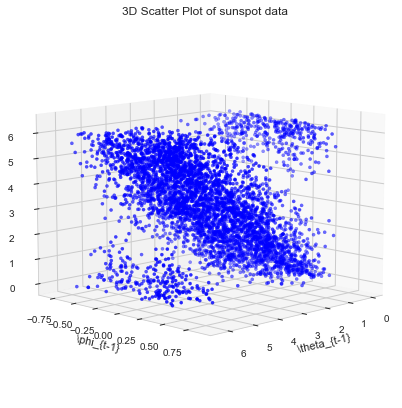

In [192]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting

# Assuming your data is already loaded, for example:
# train_theta_x, train_phi_x, and train_theta_y are already defined as arrays
for i in range(19, 20):
    print(i)
    with open(os.path.join(os.getcwd(), 'sunspots', 'data', 'sunspots_cycle_' + str(i) + '.csv'), 'rb') as f:
        sample = pd.read_csv(f)
    sample.drop(columns = ['Unnamed: 0'], inplace = True)
    train_theta_x = sample['theta_pred'].to_numpy()
    train_phi_x = sample['phi_pred'].to_numpy()
    train_theta_y = sample['theta_resp'].to_numpy()
    train_phi_y = sample['phi_resp'].to_numpy()

    train_predictors = np.vstack((train_theta_x, train_phi_x)).T
    # Perform hyperparameter tuning
    theta_forest = tune_forest(train_predictors, train_phi_y, param_grid)
    random_forests.append(theta_forest)
    X_trains.append(train_predictors)
    y_trains.append(train_phi_y)

    # Create a 3D plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot: x is train_theta_x, y is train_phi_x, z is train_theta_y
    ax.scatter(train_theta_x, train_phi_x, train_theta_y, color='b', marker='o', s=10)
    ax.view_init(elev=10, azim=45, roll = 0)

    # Labels for axes
    ax.set_xlabel(r'\theta_{t-1}')
    ax.set_ylabel(r'\phi_{t-1}')
    ax.set_zlabel(r'\theta_t')

    # Set title for the plot
    ax.set_title('3D Scatter Plot of sunspot data')
    # Show plot
    plt.show()


19


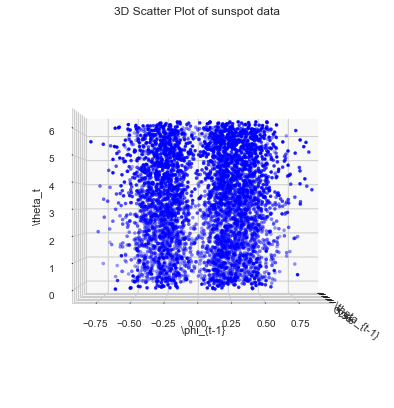

In [193]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting

# Assuming your data is already loaded, for example:
# train_theta_x, train_phi_x, and train_theta_y are already defined as arrays
for i in range(19, 20):
    print(i)
    with open(os.path.join(os.getcwd(), 'sunspots', 'data', 'sunspots_cycle_' + str(i) + '.csv'), 'rb') as f:
        sample = pd.read_csv(f)
    sample.drop(columns = ['Unnamed: 0'], inplace = True)
    train_theta_x = sample['theta_pred'].to_numpy()
    train_phi_x = sample['phi_pred'].to_numpy()
    train_theta_y = sample['theta_resp'].to_numpy()
    train_phi_y = sample['phi_resp'].to_numpy()

    train_predictors = np.vstack((train_theta_x, train_phi_x)).T
    # Perform hyperparameter tuning
    theta_forest = tune_forest(train_predictors, train_phi_y, param_grid)
    random_forests.append(theta_forest)
    X_trains.append(train_predictors)
    y_trains.append(train_phi_y)

    # Create a 3D plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot: x is train_theta_x, y is train_phi_x, z is train_theta_y
    ax.scatter(train_theta_x, train_phi_x, train_theta_y, color='b', marker='o', s=10)
    ax.view_init(elev=0, azim=0, roll = 0)

    # Labels for axes
    ax.set_xlabel(r'\theta_{t-1}')
    ax.set_ylabel(r'\phi_{t-1}')
    ax.set_zlabel(r'\theta_t')

    # Set title for the plot
    ax.set_title('3D Scatter Plot of sunspot data')
    # Show plot
    plt.show()


19


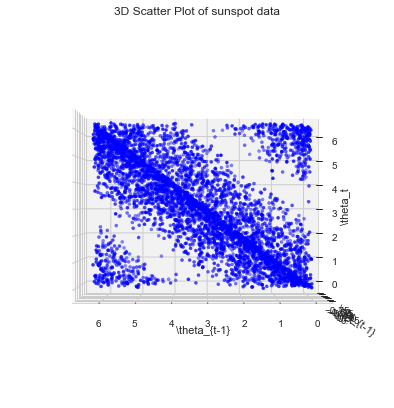

In [195]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting

# Assuming your data is already loaded, for example:
# train_theta_x, train_phi_x, and train_theta_y are already defined as arrays
for i in range(19, 20):
    print(i)
    with open(os.path.join(os.getcwd(), 'sunspots', 'data', 'sunspots_cycle_' + str(i) + '.csv'), 'rb') as f:
        sample = pd.read_csv(f)
    sample.drop(columns = ['Unnamed: 0'], inplace = True)
    train_theta_x = sample['theta_pred'].to_numpy()
    train_phi_x = sample['phi_pred'].to_numpy()
    train_theta_y = sample['theta_resp'].to_numpy()
    train_phi_y = sample['phi_resp'].to_numpy()

    train_predictors = np.vstack((train_theta_x, train_phi_x)).T
    # Perform hyperparameter tuning
    theta_forest = tune_forest(train_predictors, train_phi_y, param_grid)
    random_forests.append(theta_forest)
    X_trains.append(train_predictors)
    y_trains.append(train_phi_y)

    # Create a 3D plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot: x is train_theta_x, y is train_phi_x, z is train_theta_y
    ax.scatter(train_theta_x, train_phi_x, train_theta_y, color='b', marker='o', s=10)
    ax.view_init(elev=0, azim=90, roll = 0)

    # Labels for axes
    ax.set_xlabel(r'\theta_{t-1}')
    ax.set_ylabel(r'\phi_{t-1}')
    ax.set_zlabel(r'\theta_t')

    # Set title for the plot
    ax.set_title('3D Scatter Plot of sunspot data')
    # Show plot
    plt.show()


In [116]:
with open(os.path.join(os.getcwd(), 'sunspots', 'data', 'sunspots_data.csv'), 'rb') as f:
    sample = pd.read_csv(f)

sample.drop(columns = ['Unnamed: 0'], inplace = True)
train_theta_x = sample['V1'].to_numpy()[:-500]
train_phi_x = sample['V2'].to_numpy()[:-500]
train_theta_y = sample['V3'].to_numpy()[:-500]
train_phi_y = sample['V4'].to_numpy()[:-500]

In [108]:
for i in range(24, 25):
    with open(os.path.join(os.getcwd(), 'sunspots', 'data', 'sunspots_cycle_' + str(i) + '.csv'), 'rb') as f:
        sample2 = pd.read_csv(f)
    sample2.drop(columns = ['Unnamed: 0'], inplace = True)
sample2

,theta_pred,phi_pred,theta_resp,phi_resp
0,3.232873,0.468621,3.164282,0.397062
1,3.164282,0.397062,2.531600,0.547859
2,2.531600,0.547859,2.579946,-0.442266
3,2.579946,-0.442266,0.520632,-0.062483
4,0.520632,-0.062483,1.020494,-0.075922
...,...,...,...,...
4844,5.608616,0.464607,5.231101,-0.010123
4845,5.231101,-0.010123,5.015378,0.349240
4846,5.015378,0.349240,4.323355,0.270701
4847,4.323355,0.270701,5.515240,0.133867


In [87]:
diff = sample['V1'] - sample2['theta_pred']

            V1        V2        V3        V4
0     2.888171  0.176453  3.535513  0.267384
1     3.535513  0.267384  2.317448  0.451691
2     2.317448  0.451691  1.237788  0.505622
3     1.237788  0.505622  1.010895  0.052360
4     1.010895  0.052360  0.736005  0.166330
...        ...       ...       ...       ...
5367  4.385314  0.626573  3.832918  0.383798
5368  3.832918  0.383798  2.095966  0.574213
5369  2.095966  0.574213  2.354973 -0.077667
5370  2.354973 -0.077667  0.104371  0.036303
5371  0.104371  0.036303  4.584980 -0.168773

[5372 rows x 4 columns]


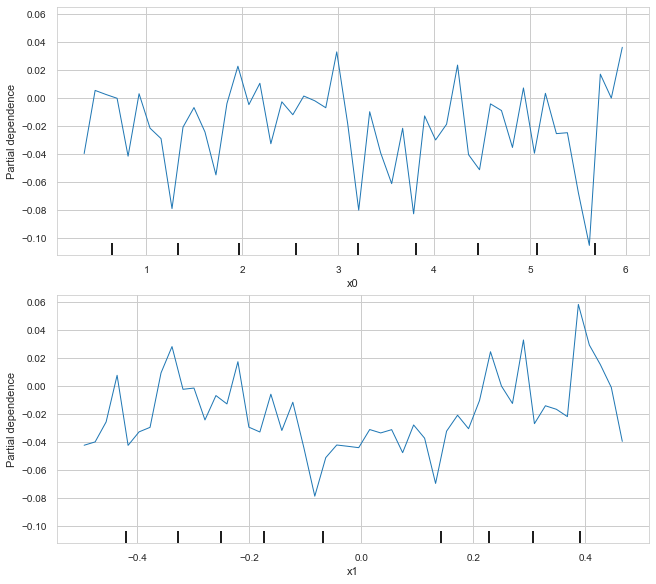

In [96]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from time import time
import seaborn as sns

# Load 30 random forests
#OJO CAMBIA ESTO

# List of all random forests (loaded in a loop)
random_forests = []
X_trains = []
y_trains = []

# Loop through the 30 models
for i in range(11, 25):
    with open(os.path.join(os.getcwd(), 'sunspots', 'data', 'sunspots_data.csv'), 'rb') as f:
        sample = pd.read_csv(f)
    sample.drop(columns = ['Unnamed: 0'], inplace = True)
    print(sample)

    train_theta_x = sample['V1'].to_numpy()[:-500]
    train_phi_x = sample['V2'].to_numpy()[:-500]
    train_theta_y = sample['V3'].to_numpy()[:-500]
    train_phi_y = sample['V4'].to_numpy()[:-500]

    train_predictors = np.vstack((train_theta_x, train_phi_x)).T
    # Perform hyperparameter tuning
    phi_forest = tune_forest(train_predictors, train_phi_y, param_grid) 
    random_forests.append(phi_forest)
    X_trains.append(train_predictors)
    y_trains.append(train_phi_y)

# Define the features of interest (same for all models)
features_info = {
    "features": [0, 1], 
    "kind": "average",  # Type of partial dependence plot (average over other features)
}

common_params = {
    "subsample": 50,
    "n_jobs": 10,
    "grid_resolution": 50,
    "random_state": 0,
}

# Set custom matplotlib style
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-notebook")

# Create a subplot for the PDPs of all models
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(9, 8), constrained_layout=True)
# Loop through all Random Forests and plot their partial dependence plots
line_kw = {"linewidth": 1}  # Set the desired linewidth here

for j, random_forest in enumerate(random_forests):
    # Generate the Partial Dependence Display for the current Random Forest
    display = PartialDependenceDisplay.from_estimator(
        random_forest, 
        X_trains[j], 
        **features_info, 
        ax=ax, 
        line_kw=line_kw,  # Apply the linewidth setting
        **common_params
    )

In [85]:
sample2['theta_pred'][0]

2.88817084620022

In [ ]:
# Create plot in 3 dimensions with theta_pred_y as response and theta_pred_x and phi_pred_x as predictors





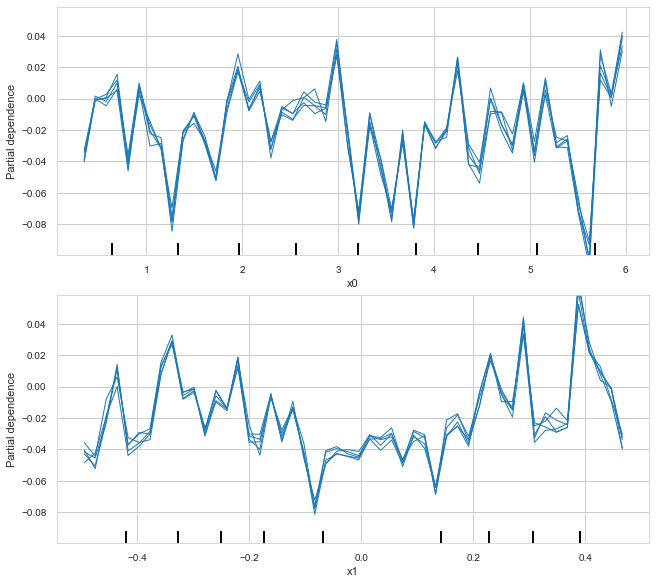

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from time import time
import seaborn as sns

# Load 30 random forests
#OJO CAMBIA ESTO
results_dir = os.path.join(os.getcwd(), 'simulations_euc', 'results')

# Define the range of random forest model files (1 to 30)
num_forests = 5

# List of all random forests (loaded in a loop)
random_forests = []
X_trains = []
y_trains = []

# Loop through the 30 models
for i in range(1, num_forests + 1):
        
    # Extract the Random Forest and data
    phi_forest = tune_forest(train_predictors, train_phi_y, param_grid, random_state=i)
    random_forests.append(phi_forest)
    X_trains.append(train_predictors)
    y_trains.append(train_phi_y)

# Define the features of interest (same for all models)
features_info = {
    "features": [0, 1], 
    "kind": "average",  # Type of partial dependence plot (average over other features)
}

common_params = {
    "subsample": 50,
    "n_jobs": 2,
    "grid_resolution": 50,
    "random_state": 0,
}

# Generate x values for plotting the theoretical functions
x = np.linspace(-5, 5, 100)

# Set custom matplotlib style
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-notebook")

# Create a subplot for the PDPs of all models
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(9, 8), constrained_layout=True)
# Loop through all Random Forests and plot their partial dependence plots
line_kw = {"linewidth": 1}  # Set the desired linewidth here

for j, random_forest in enumerate(random_forests):
    # Generate the Partial Dependence Display for the current Random Forest
    display = PartialDependenceDisplay.from_estimator(
        random_forest, 
        X_trains[j], 
        **features_info, 
        ax=ax, 
        line_kw=line_kw,  # Apply the linewidth setting
        **common_params
    )

In [ ]:

############################################################################################################
# TYPE I COVERAGE RESULTS
n_estimations = 50
pb_i_cov = np.zeros(shape = (n_estimations, 3))
conf_i_cov = np.zeros(shape = (n_estimations, 3))

for estimation in range(n_estimations):
    # Randomly select rows from the dataframe
    new_X = 2*np.sqrt(5)*(np.random.beta(2, 2, (1, n_predictors)) - 1/2)
    # Add a column of ones for the intercept (beta_0)
    new_X, new_y = simulate_data(sigma = true_sigma, X_design=new_X, betas=betas)
    new_X = new_X.reshape(1, n_predictors)

    # Predict the new observation
    pb_new_pred = pb_forest.predict(new_X)
    conf_new_pred = conf_forest.predict(new_X)

    pb_i_cov[estimation, :] = (np.abs(pb_new_pred - new_y) <= oob_quantile)
    conf_i_cov[estimation, :] = (np.abs(conf_new_pred - new_y) <= quantile)
        

############################################################################################################            
# TYPE II COVERAGE RESULTS
MC = 500
#Generate observations to estimate the probability

theta_new_pred = theta_forest.predict(test_predictors)
phi_new_pred = phi_forest.predict(test_predictors)

theta_ii_cov = np.sum(np.abs(theta_new_pred - test_theta_y).reshape(-1,1) <= np.tile(theta_oob_quantile, (MC, 1)), axis = 0) / MC
phi_ii_cov = np.sum(np.abs(phi_new_pred - test_phi_y).reshape(-1,1) <= np.tile(phi_oob_quantile, (MC, 1)), axis = 0) / MC

############################################################################################################
q_25 = 2*np.sqrt(5)*(beta(2,2).ppf(.25)-1/2)
# TYPE III COVERAGE RESULTS
pb_iii_cov = np.zeros(shape = (n_estimations, 3))
conf_iii_cov = np.zeros(shape = (n_estimations, 3))

for estimation in range(n_estimations):
    # Randomly select rows from the dataframe
    new_X = np.repeat(q_25, n_predictors).reshape(1, n_predictors)
    # Add a column of ones for the intercept (beta_0)
    new_X, new_y = simulate_data(sigma = true_sigma, X_design=new_X, betas=betas)

    # Predict the new observation
    pb_new_pred = pb_forest.predict(new_X)
    conf_new_pred = conf_forest.predict(new_X)

    pb_iii_cov[estimation, :] = (np.abs(pb_new_pred - new_y) <= oob_quantile)
    conf_iii_cov[estimation, :] = (np.abs(conf_new_pred - new_y) <= quantile)

############################################################################################################
# TYPE IV COVERAGE RESULTS
#Generate observations to estimate the probability
new_X = np.repeat(q_25, MC * n_predictors).reshape(MC, n_predictors)
new_X, new_y = simulate_data(sigma = true_sigma, X_design=new_X, betas = betas)

pb_new_pred = pb_forest.predict(new_X)
conf_new_pred = conf_forest.predict(new_X)

pb_iv_cov = np.sum(np.abs(pb_new_pred.reshape(-1,1) - new_y).reshape(-1,1) <= np.tile(oob_quantile, (MC, 1)), axis = 0) / MC
conf_iv_cov = np.sum(np.abs(conf_new_pred.reshape(-1,1) - new_y).reshape(-1,1) <= np.tile(quantile, (MC, 1)), axis = 0) / MC

# Store results
results = {
    'pb_i_cov': pb_i_cov,
    'conf_i_cov': conf_i_cov,
    'pb_ii_cov': pb_ii_cov,
    'conf_ii_cov': conf_ii_cov,
    'pb_iii_cov': pb_iii_cov,
    'conf_iii_cov': conf_iii_cov,
    'pb_iv_cov': pb_iv_cov,
    'conf_iv_cov': conf_iv_cov,
    'OOB_quantile': oob_quantile,
    'quantile': quantile,
    'pb_time': pb_time,
    'conf_time': conf_time,
}
filename = os.path.join(results_dir, file[:-4] + '_results.npy')
np.save(filename, results)